In [1]:
%load_ext autoreload
%autoreload 2

import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.experiments_analysis.cell_typing_pipeline import (
    compare_cell_types,
    load_benchmark_config,
    load_pipeline_results,
    run_pipeline,
)

logging.basicConfig(level=logging.INFO)

## Configuration

In [2]:
cfg = load_benchmark_config("experiments/benchmark_output_files/mouse_brain.yaml")

SDATA_PATH = cfg["sdata_path"]
METHODS = cfg["methods"]
LABELS_KEY = cfg["cell_id_label"]
OUTPUT_DIR = "results/my_notebooks/cell_typing_mouse_brain"
CELL_TYPING_MODEL = "Mouse_Whole_Brain.pkl"

print(f"Dataset: {SDATA_PATH}")
print(f"Labels key: {LABELS_KEY}")
for name, path in METHODS.items():
    print(f"  {name}: {path}")

Dataset: results/Visium_HD_Mouse_Brain_tissue/stardist_segmentation__24_02_25__18_08_11/sdata
Labels key: labels_he
  ours: results/benchmark_destriping_model/mouse_brain_v3/Glum_benchmark_v3/v3/2025-12-30/10-02-15/0__+dataset=mouse_brain/destriped_data/cyto_destripe_dividing_factors_nucl_destripe_dividing_factors_qm_tot_counts/df.parquet
  original: results/benchmark_destriping_model/mouse_brain_v2/dividing_by_factors/2025-12-19/02-18-00/1__factors=ones/destriped_data/df.parquet
  b2c: results/benchmark_destriping_model/mouse_brain_v2/b2c_destriping/2025-12-19/13-42-27/0__+dataset=mouse_brain/destriped_data/df.parquet
  b2c-sym: results/benchmark_destriping_model/mouse_brain_v2/dividing_by_factors/2025-12-19/02-18-00/0__factors=quantiles/destriped_data/df.parquet


## Run Pipeline
Rescale → bin2cell → cell typing for each method. Results are saved to disk.

In [3]:
cell_sdatas = run_pipeline(
    sdata_path=SDATA_PATH,
    methods=METHODS,
    output_dir=OUTPUT_DIR,
    labels_key=LABELS_KEY,
    cell_typing_model=CELL_TYPING_MODEL,
)
print(f"Methods processed: {list(cell_sdatas.keys())}")
for name, sd in cell_sdatas.items():
    print(f"  {name}: {sd.adata.shape[0]} cells, {sd.adata.shape[1]} genes")

Loading original sdata from results/Visium_HD_Mouse_Brain_tissue/stardist_segmentation__24_02_25__18_08_11/sdata
Processing method: ours
  Saved binned sdata to results/my_notebooks/cell_typing_mouse_brain/binned_sdata/ours
🔬 Input data has 61842 cells and 18823 genes
🔗 Matching reference genes in the model
🧬 4603 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
  Saved cell-typed sdata to results/my_notebooks/cell_typing_mouse_brain/cell_typed_sdata/ours
Processing method: original
  Saved binned sdata to results/my_notebooks/cell_typing_mouse_brain/binned_sdata/original
🔬 Input data has 61842 cells and 18823 genes
🔗 Matching reference genes in the model
🧬 4603 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
  Saved cell-typed sdata to results/my_notebooks/cell_typing_mouse_brain/cell_typed_sdata/original
Processing method: b2c
  Saved binned sdata to results/my_notebooks/cell_typing_mouse_brain/binne

Methods processed: ['ours', 'original', 'b2c', 'b2c-sym']
  ours: 61842 cells, 18823 genes
  original: 61842 cells, 18823 genes
  b2c: 61842 cells, 18823 genes
  b2c-sym: 61842 cells, 18823 genes


In [4]:
# To reload saved results without rerunning the pipeline, uncomment below:
# cell_sdatas = load_pipeline_results(OUTPUT_DIR)

## Pairwise Agreement Between Methods

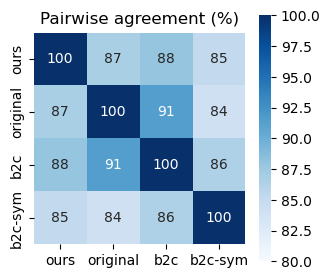

In [10]:
from pathlib import Path as P

ct_comparison = compare_cell_types(cell_sdatas)
agreement = ct_comparison["agreement"]

# Build a symmetric agreement matrix
methods = list(cell_sdatas.keys())
mat = pd.DataFrame(1.0, index=methods, columns=methods)
for _, row in agreement.iterrows():
    mat.loc[row["method_1"], row["method_2"]] = row["agreement_fraction"]
    mat.loc[row["method_2"], row["method_1"]] = row["agreement_fraction"]

mat_pct = mat * 100

savepath = "results/publication_oup_vrepro/downstream_tasks/cell_typing_mouse_brain/pairwise_agreement.pdf"
P(savepath).parent.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(3.4, 3))
sns.heatmap(mat_pct, annot=True, fmt=".0f", cmap="Blues", vmin=80, vmax=100, square=True, ax=ax)
ax.set_title("Pairwise agreement (%)")
plt.tight_layout()
plt.savefig(savepath)
plt.show()